# CIS I — Assignment 1: Pivot Calibration

This notebook walks through the pivot-calibration scenario from the
assignment (Figure 1): a pointer and a calibration object, each
carrying a marker body, observed by an optical tracker. Your job is to
**design** the marker-sphere layouts and workspace placements, then
**calibrate** the pointer's tip position `p_tip` to within about 2mm.

Everything runs against `src.simulation`, a self-contained simulator that plays the role of the physical tracker +
hand-guided robot + calibration sensor described in the handout. It injects measurement noise — your code never sees ground truth
except where explicitly noted for **validation/reporting** in Step 8 (real
hardware wouldn't give you that; the point there is to report your achieved
accuracy, not to use the ground truth in your calibration math itself).



In [73]:
import sys, os

# Add the assignment root so the local src package can be imported when this
# notebook is launched from the notebooks directory.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import unittest
from types import SimpleNamespace
from src import simulation
from src import vct3, Rot, Frame

# Fix the Monte-Carlo sequence so calibration and validation are reproducible.
np.random.seed(7)
# Print small matrices compactly while retaining millimetre-level precision.
np.set_printoptions(precision=3, suppress=True)


## Step 1: Design the pointer's marker body

Choose approximate local marker-sphere positions `a_ptr,k` (a `List[vct3]`,
relative to the pointer's own coordinate frame) and the pointer tip's
approximate local position `p_tip_approx`. These are your
*nominal design values* — the simulator will independently perturb the
*actual* manufactured positions by a small, noise amount (bounded at
2mm).


In [74]:
# Every rigid body uses the same five-point, noncoplanar topology.
MARKERS_PER_BODY = 5
PTR_RADIUS_MM = 120.0
# Three markers form an equilateral triangle in the xy plane; the remaining
# two markers provide symmetric positive/negative z depth. This gives full
# three-dimensional rotational information instead of a planar layout.
ptr_local_positions = [
    vct3(PTR_RADIUS_MM, 0.0, 0.0),
    vct3(-PTR_RADIUS_MM / 2.0, np.sqrt(3.0) * PTR_RADIUS_MM / 2.0, 0.0),
    vct3(-PTR_RADIUS_MM / 2.0, -np.sqrt(3.0) * PTR_RADIUS_MM / 2.0, 0.0),
    vct3(0.0, 0.0, np.sqrt(3.0) * PTR_RADIUS_MM / 2.0),
    vct3(0.0, 0.0, -np.sqrt(3.0) * PTR_RADIUS_MM / 2.0),
]
# Fail immediately if a future edit breaks the required five-marker count.
assert len(ptr_local_positions) == MARKERS_PER_BODY
# Nominal pointer tip in the pointer marker-body frame.
ptr_tip_approx = vct3(0.0, 0.0, -150.0)


## Step 1.1: Design the calibration object's marker body

Same idea, for the calibration object's local marker positions `a_cal,k`.


In [75]:
# Use the same isotropic five-point topology at the calibration-body scale.
CAL_RADIUS_MM = 280.0
cal_local_positions = [
    vct3(CAL_RADIUS_MM, 0.0, 0.0),
    vct3(-CAL_RADIUS_MM / 2.0, np.sqrt(3.0) * CAL_RADIUS_MM / 2.0, 0.0),
    vct3(-CAL_RADIUS_MM / 2.0, -np.sqrt(3.0) * CAL_RADIUS_MM / 2.0, 0.0),
    vct3(0.0, 0.0, np.sqrt(3.0) * CAL_RADIUS_MM / 2.0),
    vct3(0.0, 0.0, -np.sqrt(3.0) * CAL_RADIUS_MM / 2.0),
]
# Enforce the 5+5+5 design requirement at construction time.
assert len(cal_local_positions) == MARKERS_PER_BODY


## Step 2: Approximate workspace poses

Specify approximate poses (as `Frame` class from src) for the tracking camera
(`F_tracker`) and the calibration object (`F_cal`), relative to the
workspace. The tracker's usable volume is the tetrahedral region in the
handout's Figure 2 (roughly 100-200cm in front of the tracker, widening
from ~120cm to ~200cm across) — place the calibration object, and later
the pointer, so they're inside that volume.


In [76]:
# Frames map local coordinates into the common workspace frame. Identity
# rotations keep the intended optical and body axes easy to inspect.
F_tracker_approx = Frame(Rot.eye(), vct3(300.0, -1500.0, 300.0))
F_cal_approx = Frame(Rot.eye(), vct3(300.0, 402.0, 892.5))


## Step 3: Build the simulation

Fully provided — this just wires up your Step 1/2 design choices through
`simulation`'s `DefineMarkerBody` / `PlaceMarkerBody` / `CreateTracker`
equivalents. `ptr_placed`/`cal_placed` are `PlacedBody` handles: each pairs
a `MarkerBody` with its hidden actual placement, and gets passed to
`simulation.sample_marker_bodies(...)` whenever you want a reading.


In [77]:
# Define the nominal rigid-body marker models. The simulator separately
# samples their hidden manufactured marker coordinates.
ptr_mb = simulation.define_marker_body("ptr_mb", ptr_local_positions)
cal_mb = simulation.define_marker_body("cal_mb", cal_local_positions)

# Place the static calibration object near the intended sensing region.
cal_placed = simulation.place_marker_body(cal_mb, F_cal_approx)
# The pointer's own body doesn't have a meaningful "workspace placement" yet
# It moves every time it's hand-guided (Step 4-6). 
# precision="precise" matches a robot-controlled pose rather than a coarsely, manually placed
# static object (see place_marker_body's docstring).
ptr_placed = simulation.place_marker_body(ptr_mb, Frame.eye(), precision="precise")

# Bind the nominal tip to the pointer marker body, then create the tracker.
ptr = simulation.define_pointer("ptr1", ptr_tip_approx, ptr_mb)
trk = simulation.create_tracker("trk1", F_tracker_approx)

print("simulation built:", ptr_mb.name, cal_mb.name, ptr.name, trk.name)


simulation built: ptr_mb cal_mb ptr1 trk1


## Step 3.1: Refine `a_ptr,k` / `a_cal,k`

> "Observations of marker positions can be used to determine accurate
> estimates of relative positions a_ptr,k of markers on pointer and
> calibration objects... **Hint**: You probably want to take multiple
> readings in order to reduce the uncertainty associated with the a_k
> values."



Step 3.1 refinement change from the nominal model (mm)
Body          M1  M2  M3  M4  M5  Mean
Pointer       1.046  1.169  1.105  1.658  1.568  1.309
Calibration   0.237  0.891  0.582  1.112  0.583  0.681


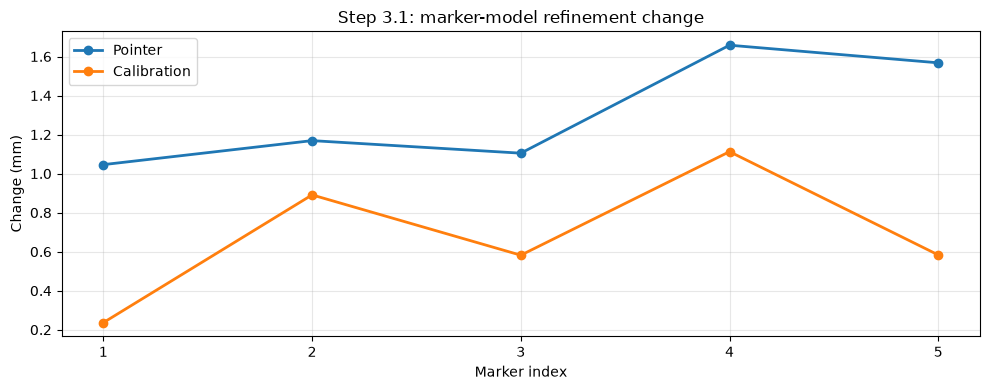

In [78]:
# -------------------------------------------------------------------------
# Step 3.1 helpers: validate a marker layout and estimate refined local
# marker coordinates from repeated tracker observations.
# -------------------------------------------------------------------------
def _point_matrix(points):
    """Return marker coordinates as an (N, 3) floating-point array."""
    return np.vstack([point.vec.ravel() for point in points])


def _validate_marker_geometry(points):
    """Require at least four finite, noncoplanar marker coordinates."""
    coordinates = _point_matrix(points)
    # Four finite points are the minimum needed for a noncoplanar 3-D body.
    if len(points) < 4 or not np.all(np.isfinite(coordinates)):
        raise ValueError("Marker geometry requires at least four finite points.")
    # Centering removes translation. Rank three then confirms that the
    # marker offsets span x, y, and z rather than a line or plane.
    if np.linalg.matrix_rank(coordinates - coordinates.mean(axis=0)) < 3:
        raise ValueError("Marker geometry must be noncoplanar.")


def _inverse_average_marker_batch(batch):
    """Average paired tracker measurements after inverse pose transformation."""
    if not batch:
        raise ValueError("At least one observation is required.")
    marker_count = len(batch[0].markers)
    # Correspondence by marker index must be identical in every snapshot.
    if marker_count < 4 or any(len(observation.markers) != marker_count for observation in batch):
        raise ValueError("Every observation must contain the same marker correspondences.")
    # Each observed marker is expressed in tracker coordinates. Applying the
    # inverse estimated body frame maps it back into that body's local frame.
    # Resulting shape: (number of snapshots, number of markers, xyz).
    local_samples = np.array([
        [(observation.frame.inv() * marker.p).vec.ravel() for marker in observation.markers]
        for observation in batch
    ])
    # Average each corresponding marker over snapshots to reduce independent
    # tracker detection noise before updating the nominal marker model.
    means = local_samples.mean(axis=0)
    return [vct3(row) for row in means]


def refine_marker_body(trk, placed, n_readings=30, passes=3):
    """Refine local marker coordinates by alternating SVD registration and averaging.

    Args:
        trk: Tracker used for simultaneous marker measurements.
        placed: PlacedBody whose marker model is updated in place.
        n_readings: Number of independent snapshots in each refinement pass.
        passes: Number of alternating registration-and-average passes.

    Returns:
        None. The body's nominal_marker_positions are updated in place.
    """
    if not isinstance(n_readings, int) or not isinstance(passes, int) or n_readings < 1 or passes < 1:
        raise ValueError("n_readings and passes must be positive integers.")
    _validate_marker_geometry(placed.body.nominal_marker_positions)
    # Registration depends on the current nominal geometry. Repeating the
    # register-average-update cycle lets the model converge iteratively.
    for _ in range(passes):
        batch = [
            simulation.sample_marker_bodies(trk, [placed])[placed.body.name]
            for _ in range(n_readings)
        ]
        placed.body.set_marker_positions(_inverse_average_marker_batch(batch))


# Preserve the pre-refinement coordinates so the real simulation update can
# be reported marker by marker after the unit-tested function is applied.
initial_marker_models = {
    "Pointer": _point_matrix(ptr_mb.nominal_marker_positions),
    "Calibration": _point_matrix(cal_mb.nominal_marker_positions),
}
refine_marker_body(trk, ptr_placed)
refine_marker_body(trk, cal_placed)
# Euclidean displacement of every refined marker from its nominal location.
refinement_changes = {
    "Pointer": np.linalg.norm(_point_matrix(ptr_mb.nominal_marker_positions) - initial_marker_models["Pointer"], axis=1),
    "Calibration": np.linalg.norm(_point_matrix(cal_mb.nominal_marker_positions) - initial_marker_models["Calibration"], axis=1),
}

marker_indices = np.arange(1, MARKERS_PER_BODY + 1)
print("\nStep 3.1 refinement change from the nominal model (mm)")
print("Body          " + "  ".join(f"M{k}" for k in marker_indices) + "  Mean")
for body_name, changes in refinement_changes.items():
    print(f"{body_name:<13} " + "  ".join(f"{value:5.3f}" for value in changes) + f"  {changes.mean():5.3f}")

# Plot the same per-marker changes printed above for a direct visual check.
x_positions = marker_indices
figure, axis = plt.subplots(figsize=(10, 4))
for body_name, changes in refinement_changes.items():
    axis.plot(x_positions, changes, marker="o", linewidth=2, label=body_name)
axis.set(title="Step 3.1: marker-model refinement change", xlabel="Marker index", ylabel="Change (mm)")
axis.set_xticks(x_positions)
axis.grid(alpha=0.3)
axis.legend()
plt.tight_layout()
plt.show()


## Steps 4-6: Collect pivot-calibration observations

For each observation `j`: hand-guide the pointer near the calibration
object at some desired orientation `R_desired,j`, take one simultaneous
tracker reading of *both* bodies, and read the calibration sensor. Loop
skeleton is provided; you choose how many observations to take, how to
vary `R_desired,j`, and what to do when the calibration sensor reports the
tip as out of range (`sense_tip` returns `None`).


In [79]:
# Collect 60 valid paired observations. The larger attempt limit prevents an
# infinite loop if some hand-guided tips fall outside the 5 mm sensor range.
N_OBSERVATIONS = 60
MAX_GUIDE_ATTEMPTS = 10 * N_OBSERVATIONS

F_ptr_list = []
F_cal_list = []
sensed_tip_list = []
guide_attempts = 0
while len(F_ptr_list) < N_OBSERVATIONS and guide_attempts < MAX_GUIDE_ATTEMPTS:
    # Sweep a deterministic phase through x tilt, y tilt, and z roll. The
    # changing orientations expose the calibration to diverse pose errors.
    phase = 2.0 * np.pi * guide_attempts / N_OBSERVATIONS
    R_desired = Rot.xyz(
        (np.pi / 3.0) * np.sin(phase),
        (np.pi / 3.0) * np.cos(phase),
        phase,
    )
    # Hand-guide the pointer tip near the calibration sensor, then acquire the
    # pointer and calibration bodies in one shared tracker snapshot.
    hg = simulation.hand_guide_pointer(ptr, ptr_placed, cal_placed, R_desired)
    obs = simulation.sample_marker_bodies(trk, [ptr_placed, cal_placed])
    # The sensor reports the tip in the calibration-object frame, or None if
    # the true tip lies outside its valid range.
    sensed = simulation.sense_tip(ptr, hg)
    guide_attempts += 1

    # Discard an invalid sensor reading together with its paired frame estimates.
    if sensed is None:
        continue
    # Keep the three values as an inseparable tuple of one observation:
    # pointer-to-tracker frame, calibration-to-tracker frame, sensed tip.
    F_ptr_list.append(obs["ptr_mb"].frame)
    F_cal_list.append(obs["cal_mb"].frame)
    sensed_tip_list.append(sensed)

# Stop with an explicit error instead of silently calibrating from too few
# valid sensor readings.
if len(F_ptr_list) < N_OBSERVATIONS:
    raise RuntimeError("Unable to collect enough valid calibration-sensor observations.")
print(f"collected {len(F_ptr_list)} valid observations in {guide_attempts} hand-guide attempts")


collected 60 valid observations in 62 hand-guide attempts


`sensed_tip_list` holds each observation's high-accuracy calibration-sensor
reading `p_sensed,j`: the pointer tip's position relative to the
calibration object's coordinate system, measured to negligible error (or
`None` if that observation ended up outside the sensor's 5mm range). The
hand-guided tip only lands *approximately* at the calibration object's
origin, so the sensor tells you exactly where it actually was for each
observation — an input to Step 7, together with `F_ptr,j` and `F_cal,j`.


## Step 7: Compute a calibrated value for `p_tip`

This is the assignment's core deliverable — implement it yourself and specify the details of implementation in the report.

Each observation `j` gives you three measurements of the same physical
moment: `F_ptr,j` and `F_cal,j` from the tracker, and `p_sensed,j` from the
calibration sensor. Derive how they relate to the unknown `p_tip`, and use
all three in your calibration.

**Corner case to consider**: What are the corner cases you want to analyse here? (e.g. what happens to observations whose `p_sensed,j` is `None`?)

**Minimum data**: how many observations, and what about their rotations,
are needed for the stacked system to actually be solvable? How do you define whether a system is solvable here? Include that in your report


In [80]:
# -------------------------------------------------------------------------
# Step 7 solver: estimate the fixed pointer-frame tip p_tip from paired
# pointer poses, calibration-object poses, and calibration-sensor readings.
# -------------------------------------------------------------------------
def _frame_is_finite(frame):
    """Return True when every rotation and translation entry is finite."""
    return np.all(np.isfinite(frame.R.matrix)) and np.all(np.isfinite(frame.p.vec))


def compute_pivot_calibration(F_ptr_list, F_cal_list, sensed_tip_list):
    """Estimate the pointer-frame tip and covariance from paired sensor observations.

    Args:
        F_ptr_list: Pointer-to-tracker Frame estimates.
        F_cal_list: Calibration-object-to-tracker Frame estimates.
        sensed_tip_list: Tip coordinates in the calibration-object frame; invalid entries are None.

    Returns:
        A tuple containing the calibrated vct3 tip and its 3x3 covariance in mm^2.
    """
    if not (len(F_ptr_list) == len(F_cal_list) == len(sensed_tip_list)):
        raise ValueError("Pointer frames, calibration frames, and sensor readings must have equal lengths.")

    # For each valid observation, the coordinate equation is
    #     sensed_tip = R_ptr_in_cal @ p_tip + t_ptr_in_cal.
    # Rearranging gives one 3-row linear block for the unknown p_tip.
    system_blocks = []
    right_hand_sides = []
    single_observation_estimates = []
    for F_ptr, F_cal, sensed in zip(F_ptr_list, F_cal_list, sensed_tip_list):
        # A missing sensor reading carries no tip-position information.
        if sensed is None:
            continue
        # Reject corrupted pose matrices early instead of allowing NaN/Inf to
        # propagate into the least-squares solution.
        if not _frame_is_finite(F_ptr) or not _frame_is_finite(F_cal):
            raise ValueError("Frame estimates must contain finite values.")
        sensed_array = sensed.vec.ravel()
        # Ignore nonfinite or physically out-of-range calibration readings.
        if not np.all(np.isfinite(sensed_array)) or sensed.norm() > 5.0 + 1e-9:
            continue

        # Compose the two tracker-frame poses to express the pointer body in
        # the calibration-object frame used by the sensor measurement.
        F_ptr_in_cal = F_cal.inv() * F_ptr
        system_blocks.append(F_ptr_in_cal.R.matrix)
        right_hand_sides.append(sensed_array - F_ptr_in_cal.p.vec.ravel())
        # Also retain the tip estimate from this observation alone. Their
        # scatter is later used to estimate uncertainty of the sample mean.
        single_observation_estimates.append((F_ptr_in_cal.inv() * sensed).vec.ravel())

    valid_count = len(system_blocks)
    if valid_count < 2:
        raise ValueError("At least two valid observations are required for an empirical covariance.")

    # Stack N rotation blocks into A with shape (3N, 3), and N translated
    # sensor vectors into B with shape (3N,). Solve A @ p_tip ~= B.
    A = np.vstack(system_blocks)
    B = np.concatenate(right_hand_sides)
    p_tip_vector, _, rank, singular_values = np.linalg.lstsq(A, B, rcond=None)
    # A valid three-dimensional calibration must constrain all x/y/z tip
    # coordinates and must not be numerically singular.
    if rank != 3 or singular_values[-1] <= np.finfo(float).eps * singular_values[0]:
        raise ValueError("The calibration system is rank deficient.")

    # Sample covariance of individual estimates is centered.T @ centered /(N-1).
    # Dividing once more by N produces covariance of their estimated mean.
    estimates = np.vstack(single_observation_estimates)
    centered = estimates - p_tip_vector
    covariance_of_mean = centered.T @ centered / (valid_count * (valid_count - 1))
    return vct3(p_tip_vector), covariance_of_mean


# Finally apply the validated solver to the real simulated observations from
# Steps 4-6. These values are used by every Step 8 prediction.
p_tip_est, p_tip_cov = compute_pivot_calibration(F_ptr_list, F_cal_list, sensed_tip_list)


calibrated p_tip: vct3(x=-0.86, y=-1.09, z=-151.64)
Internal Vector:
[[  -0.856]
 [  -1.085]
 [-151.64 ]]
estimated covariance (mm^2):
 [[ 0. -0.  0.]
 [-0.  0.  0.]
 [ 0.  0.  0.]]
estimated std-dev per axis (mm): [0.018 0.02  0.021]


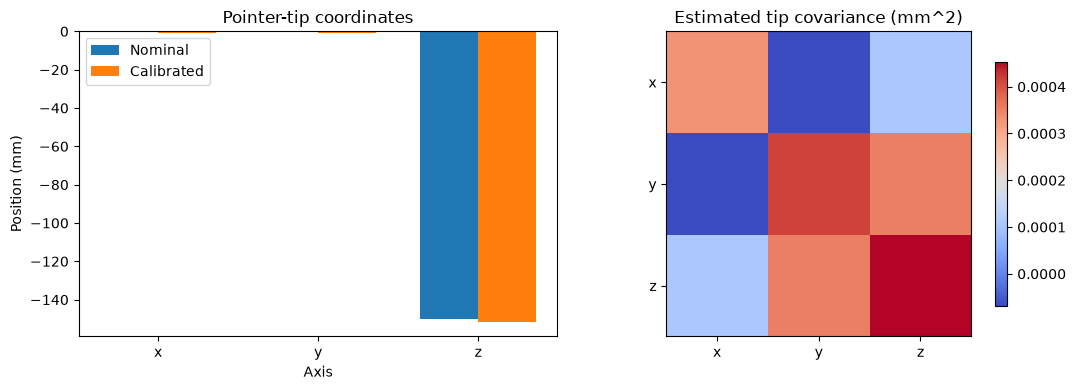

In [81]:
# Convert the covariance diagonal from variance (mm^2) to per-axis standard
# deviation (mm). clip removes tiny negative round-off values before sqrt.
tip_standard_deviation = np.sqrt(np.clip(np.diag(p_tip_cov), 0.0, None))
print("calibrated p_tip:", p_tip_est)
print("estimated covariance (mm^2):\n", p_tip_cov)
print("estimated std-dev per axis (mm):", tip_standard_deviation)

# Left: compare nominal and calibrated tip coordinates. Right: show all
# covariance terms, including any estimated cross-axis correlation.
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
coordinate_axis = np.arange(3)
axes[0].bar(coordinate_axis - 0.18, ptr_tip_approx.vec.ravel(), 0.36, label="Nominal")
axes[0].bar(coordinate_axis + 0.18, p_tip_est.vec.ravel(), 0.36, label="Calibrated")
axes[0].set(title="Pointer-tip coordinates", xlabel="Axis", ylabel="Position (mm)")
axes[0].set_xticks(coordinate_axis, ["x", "y", "z"])
axes[0].legend()
covariance_image = axes[1].imshow(p_tip_cov, cmap="coolwarm")
axes[1].set(title="Estimated tip covariance (mm^2)", xticks=coordinate_axis, yticks=coordinate_axis)
axes[1].set_xticklabels(["x", "y", "z"])
axes[1].set_yticklabels(["x", "y", "z"])
figure.colorbar(covariance_image, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()


## Step 8: Validate against test poses

> "**Hint**: You may want to consider placing additional marker bodies
> close to (but not inside) the cube defined by the test volume. However,
> this will also depend on your design for and placement of the
> calibration object."

The nominal test-pose grid is `theta_x, theta_y, theta_z` each in
`{0, +-pi/6, +-pi/3, +-pi/2}` and `p_x, p_y, p_z` each in
`{300, 300+-100, 300+-200}` mm. For each test pose, the assignment requires a
**single observation only** (no averaging).

Think about why the hint suggests an *additional*, nearby reference body?

Five-marker geometry metrics
Body                         N   Radius(mm)   Min spacing(mm)   Lambda min(mm^2)   Kappa
Pointer (R=120 mm)            5        120.0             158.7            43200.0    1.00
Calibration (R=280 mm)        5        280.0             370.4           235200.0    1.00
Nearby (R=280 mm)             5        280.0             370.4           235200.0    1.00


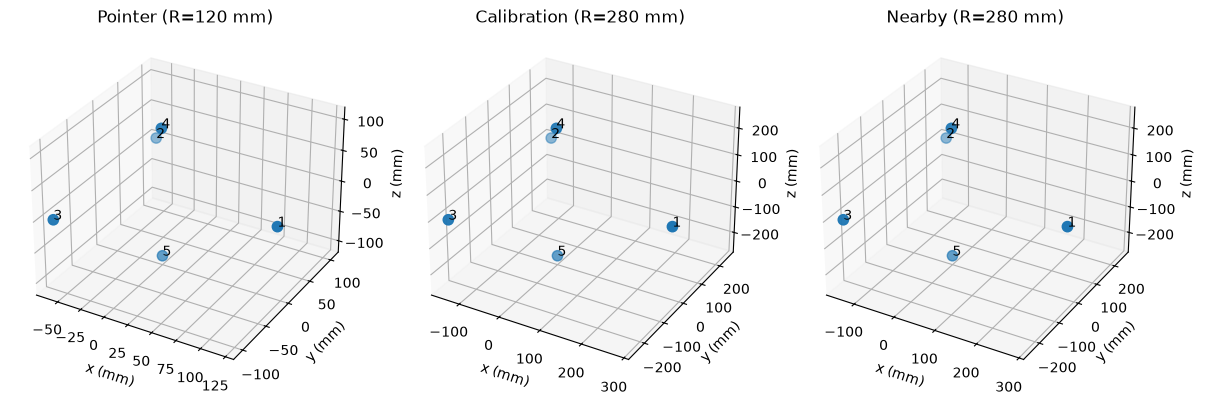

In [82]:
# The nearby reference uses the same five-marker noncoplanar topology. Its
# 280 mm radius improves rotational accuracy for points hundreds of mm away.
NEAR_RADIUS_MM = 280.0
near_local_positions = [
    vct3(NEAR_RADIUS_MM, 0.0, 0.0),
    vct3(-NEAR_RADIUS_MM / 2.0, np.sqrt(3.0) * NEAR_RADIUS_MM / 2.0, 0.0),
    vct3(-NEAR_RADIUS_MM / 2.0, -np.sqrt(3.0) * NEAR_RADIUS_MM / 2.0, 0.0),
    vct3(0.0, 0.0, np.sqrt(3.0) * NEAR_RADIUS_MM / 2.0),
    vct3(0.0, 0.0, -np.sqrt(3.0) * NEAR_RADIUS_MM / 2.0),
]
assert len(near_local_positions) == MARKERS_PER_BODY
# Position the reference beside the test cube while keeping its local axes
# aligned with the workspace axes.
F_near_approx = Frame(Rot.eye(), vct3(-210.0, 300.0, 300.0))

# Create, place, and refine the reference body exactly as for the pointer and
# calibration bodies; Step 8 will estimate all tips relative to this frame.
near_mb = simulation.define_marker_body("near_mb", near_local_positions)
near_placed = simulation.place_marker_body(near_mb, F_near_approx)
refine_marker_body(trk, near_placed)

def marker_geometry_metrics(points):
    """Return radius, spacing, and rotational information metrics for a marker body."""
    coordinates = _point_matrix(points)
    # Centering makes all metrics independent of an arbitrary local origin.
    centered = coordinates - coordinates.mean(axis=0)
    # Rotational information matrix: larger eigenvalues imply that marker
    # displacement changes more strongly under small rotations.
    information = sum(
        np.dot(point, point) * np.eye(3) - np.outer(point, point) for point in centered
    )
    eigenvalues = np.linalg.eigvalsh(information)
    pairwise_distances = [
        np.linalg.norm(coordinates[i] - coordinates[j])
        for i in range(len(coordinates)) for j in range(i + 1, len(coordinates))
    ]
    # Kappa=lambda_max/lambda_min measures directional balance; 1.0 is
    # isotropic, while larger values indicate a weaker rotation direction.
    return (
        np.linalg.norm(centered, axis=1).max(), min(pairwise_distances),
        eigenvalues[0], eigenvalues[-1] / eigenvalues[0],
    )


# Print comparable scale, separation, information, and conditioning values
# for the three five-marker bodies.
marker_layouts = {
    "Pointer (R=120 mm)": _point_matrix(ptr_local_positions),
    "Calibration (R=280 mm)": _point_matrix(cal_local_positions),
    "Nearby (R=280 mm)": _point_matrix(near_local_positions),
}
print("Five-marker geometry metrics")
print("Body                         N   Radius(mm)   Min spacing(mm)   Lambda min(mm^2)   Kappa")
for body_name, coordinates in marker_layouts.items():
    radius, spacing, lambda_min, condition_number = marker_geometry_metrics([vct3(row) for row in coordinates])
    print(f"{body_name:<28} {len(coordinates):2d}   {radius:10.1f}   {spacing:15.1f}   "
          f"{lambda_min:16.1f}   {condition_number:5.2f}")

# Display the local 3-D layouts and marker indices for visual verification.
figure = plt.figure(figsize=(12, 4))
for plot_index, (body_name, coordinates) in enumerate(marker_layouts.items(), start=1):
    axis = figure.add_subplot(1, 3, plot_index, projection="3d")
    axis.scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], s=55)
    for marker_index, coordinate in enumerate(coordinates, start=1):
        axis.text(*coordinate, str(marker_index))
    axis.set(title=body_name, xlabel="x (mm)", ylabel="y (mm)", zlabel="z (mm)")
plt.tight_layout()
plt.show()


Refine this new body's geometry the same way you refined the pointer's and
calibration object's (Step 3b) before using it.


Now the single-observation test loop. For each nominal test pose `F_t`:
place the pointer there (small, robot-precision placement error, same as
the real system), take one simultaneous reading of the pointer and your
Step-8 reference body, and predict the tip's position (relative to that
reference body) using your calibrated `p_tip`.

**Ground truth for reporting only**: `PlacedBody.actual_placement` and
`MarkerBody.actual_marker_positions` hold the hidden values the simulator
sampled — you have access to them here only because this notebook doesn't
gate them behind a separate eval mode (per the handout: "During debugging
you will have access to all of the ... values. These will not be available
during evaluation."). Use them *only* to compute and report your achieved
error in this section — using them anywhere in your actual calibration math
(Steps 3b/7) kills the point of the assignment.


In [83]:
# Candidate angle/offset values document the assignment's test envelope. The
# representative sets below avoid the full Cartesian-product explosion while
# retaining the centre, faces, corners, intermediate offsets, and large tilts.
thetas = [0, np.pi / 6, -np.pi / 6, np.pi / 3, -np.pi / 3, np.pi / 2, -np.pi / 2]
offsets = [0, 100, -100, 200, -200]
position_offsets = [
    (0, 0, 0),
    (200, 0, 0), (-200, 0, 0), (0, 200, 0), (0, -200, 0), (0, 0, 200), (0, 0, -200),
    (200, 200, 200), (200, 200, -200), (200, -200, 200), (200, -200, -200),
    (-200, 200, 200), (-200, 200, -200), (-200, -200, 200), (-200, -200, -200),
    (100, -100, 100), (-100, 100, -100),
]
orientation_angles = [
    (0, 0, 0),
    (np.pi / 6, 0, 0), (-np.pi / 6, 0, 0),
    (0, np.pi / 6, 0), (0, -np.pi / 6, 0),
    (np.pi / 3, 0, 0), (0, -np.pi / 3, 0),
    (np.pi / 2, 0, 0), (0, -np.pi / 2, 0),
    (np.pi / 6, -np.pi / 6, np.pi / 6),
]
# Form 17 positions x 10 orientations = 170 requested pointer poses.
test_poses = [
    Frame(Rot.xyz(rx, ry, rz), vct3(300 + tx, 300 + ty, 300 + tz))
    for tx, ty, tz in position_offsets
    for rx, ry, rz in orientation_angles
]

# The pointer shaft and workspace vertical both point along local/workspace -z.
# Their dot product after placement gives the actual tilt classification.
pointer_axis = vct3(0.0, 0.0, -1.0)
workspace_vertical = vct3(0.0, 0.0, -1.0)
# Hidden ground truth is retrieved only for validation, never for prediction.
actual_tip_local = ptr.get_actual_tip_position().p
test_results = []
for pose_index, F_t_nominal in enumerate(test_poses):
    # Place the pointer with the simulator's small robot-positioning error.
    test_placed = simulation.place_marker_body(ptr_mb, F_t_nominal, precision="precise")
    # Exactly one simultaneous snapshot observes Pointer and Nearby. Shared
    # tracker-frame jiggle therefore cancels in their relative transform.
    observation = simulation.sample_marker_bodies(trk, [test_placed, near_placed])

    # Prediction branch: calibrated pointer tip -> tracker frame -> estimated
    # nearby-reference frame. It uses only observable/calibrated quantities.
    predicted_tip_near = observation["near_mb"].frame.inv() * (observation["ptr_mb"].frame * p_tip_est)
    # Validation branch: use hidden actual placements and the hidden actual tip
    # only to compute the answer against which the prediction is scored.
    actual_tip_near = near_placed.actual_placement.inv() * (test_placed.actual_placement * actual_tip_local)
    error_vector = predicted_tip_near - actual_tip_near

    # Use actual rather than nominal placement to classify the final shaft tilt.
    actual_axis = test_placed.actual_placement.R * pointer_axis
    cosine_tilt = np.clip(actual_axis.dot(workspace_vertical), -1.0, 1.0)
    tilt_degrees = np.degrees(np.arccos(cosine_tilt))
    test_results.append({
        "index": pose_index,
        "nominal_pose": F_t_nominal,
        "predicted_tip_near": predicted_tip_near,
        "actual_tip_near": actual_tip_near,
        "error_vector": error_vector,
        "error_mm": error_vector.norm(),
        "tilt_deg": tilt_degrees,
        "is_core": tilt_degrees <= 45.0,
    })

print(f"evaluated {len(test_results)} representative poses with one tracker observation per pose")


evaluated 170 representative poses with one tracker observation per pose


## Achieved performance

Summarize the tip-position error across the test-pose grid against the
handout's 2mm spec.


Step 8 performance summary
Region               N    Mean(mm)   RMSE(mm)    Max(mm)   Within 2 mm
All poses            170      1.355      1.413      2.256       91.8%
Core <=45 deg        102      1.310      1.372      2.216       94.1%
Extended >45 deg      68      1.421      1.473      2.256       88.2%

Ten largest single-observation errors
Pose   Tilt(deg)   Error(mm)   Region     Meets spec
  88       92.46       2.256   extended   no
  86       57.06       2.242   extended   no
  84       29.70       2.216   core       no
  89       42.94       2.203   core       no
  85       60.11       2.133   extended   no
  79       39.65       2.112   core       no
  81       31.25       2.064   core       no
  87       89.02       2.044   extended   no
 104       28.46       2.037   core       no
 106       59.09       2.027   extended   no


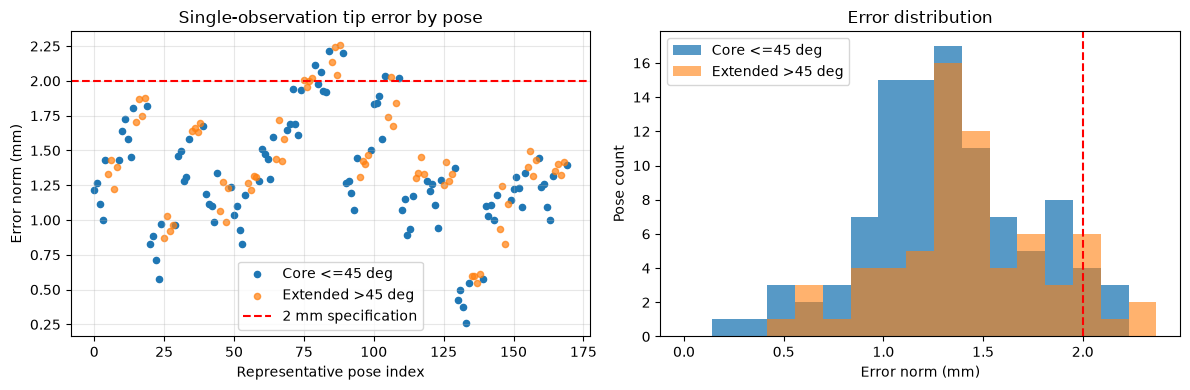

In [84]:
# Convert the recorded dictionaries into vectorized arrays for statistics.
errors = np.array([result["error_mm"] for result in test_results])
core_mask = np.array([result["is_core"] for result in test_results], dtype=bool)
core_errors = errors[core_mask]
extended_errors = errors[~core_mask]

# Report all poses, the required <=45-degree core region, and the deliberately
# more difficult extended region. Pass means Euclidean error <= 2 mm.
summary_rows = [
    ("All poses", len(errors), errors.mean(), np.sqrt(np.mean(errors ** 2)), errors.max(), np.mean(errors <= 2.0)),
    ("Core <=45 deg", len(core_errors), core_errors.mean(), np.sqrt(np.mean(core_errors ** 2)), core_errors.max(), np.mean(core_errors <= 2.0)),
    ("Extended >45 deg", len(extended_errors), extended_errors.mean(), np.sqrt(np.mean(extended_errors ** 2)), extended_errors.max(), np.mean(extended_errors <= 2.0)),
]
print("Step 8 performance summary")
print("Region               N    Mean(mm)   RMSE(mm)    Max(mm)   Within 2 mm")
for name, count, mean_error, rmse, max_error, pass_fraction in summary_rows:
    print(f"{name:<20} {count:3d}   {mean_error:8.3f}   {rmse:8.3f}   {max_error:8.3f}     {100.0 * pass_fraction:6.1f}%")

# List worst cases explicitly so a high average pass rate cannot hide isolated
# poses that violate the 2 mm specification.
print("\nTen largest single-observation errors")
print("Pose   Tilt(deg)   Error(mm)   Region     Meets spec")
for result in sorted(test_results, key=lambda item: item["error_mm"], reverse=True)[:10]:
    region = "core" if result["is_core"] else "extended"
    meets_spec = "yes" if result["error_mm"] <= 2.0 else "no"
    print(f"{result['index']:4d}   {result['tilt_deg']:9.2f}   {result['error_mm']:9.3f}   {region:<8}   {meets_spec}")

# Left: error for every individual pose. Right: core/extended distributions.
# The red line marks the same 2 mm limit used by the printed pass fractions.
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
pose_indices = np.arange(len(errors))
axes[0].scatter(pose_indices[core_mask], errors[core_mask], s=20, label="Core <=45 deg")
axes[0].scatter(pose_indices[~core_mask], errors[~core_mask], s=20, alpha=0.7, label="Extended >45 deg")
axes[0].axhline(2.0, color="red", linestyle="--", label="2 mm specification")
axes[0].set(title="Single-observation tip error by pose", xlabel="Representative pose index", ylabel="Error norm (mm)")
axes[0].grid(alpha=0.3)
axes[0].legend()
histogram_bins = np.linspace(0.0, max(2.0, errors.max()) * 1.05, 18)
axes[1].hist(core_errors, bins=histogram_bins, alpha=0.75, label="Core <=45 deg")
axes[1].hist(extended_errors, bins=histogram_bins, alpha=0.6, label="Extended >45 deg")
axes[1].axvline(2.0, color="red", linestyle="--")
axes[1].set(title="Error distribution", xlabel="Error norm (mm)", ylabel="Pose count")
axes[1].legend()
plt.tight_layout()
plt.show()


In [85]:
# -------------------------------------------------------------------------
# Shared deterministic fixtures for the standalone unit-test cells below.
# These helpers create controlled inputs with analytically known answers.
# -------------------------------------------------------------------------
def _unit_five_marker_points():
    """Return the unit-radius version of the five-marker body geometry."""
    radius = 1.0
    return [
        vct3(radius, 0.0, 0.0),
        vct3(-radius / 2.0, np.sqrt(3.0) * radius / 2.0, 0.0),
        vct3(-radius / 2.0, -np.sqrt(3.0) * radius / 2.0, 0.0),
        vct3(0.0, 0.0, np.sqrt(3.0) * radius / 2.0),
        vct3(0.0, 0.0, -np.sqrt(3.0) * radius / 2.0),
    ]


def _unit_marker_observation(points, frame, offsets=None):
    """Create a synthetic tracker observation from known local markers."""
    offsets = np.zeros((len(points), 3)) if offsets is None else offsets
    markers = [
        SimpleNamespace(p=frame * vct3(point.vec.ravel() + offset))
        for point, offset in zip(points, offsets)
    ]
    return SimpleNamespace(frame=frame, markers=markers)


def _synthetic_calibration_case():
    """Build exact paired frames whose sensor readings are analytically known."""
    true_tip = vct3(1.5, -0.75, -149.0)
    rotations = [
        Rot.eye(),
        Rot.xyz(0.4, -0.2, 0.1),
        Rot.xyz(-0.5, 0.3, -0.4),
        Rot.xyz(0.2, 0.6, -0.3),
    ]
    sensed_targets = [
        vct3(0.2, -0.1, 0.1),
        vct3(-0.2, 0.1, 0.0),
        vct3(0.0, 0.2, -0.1),
        vct3(0.1, 0.0, 0.2),
    ]
    cal_frames = [Frame.eye() for _ in rotations]
    # Choosing t = sensed - R @ true_tip makes every observation exact.
    ptr_frames = [
        Frame(rotation, sensed - rotation * true_tip)
        for rotation, sensed in zip(rotations, sensed_targets)
    ]
    return true_tip, ptr_frames, cal_frames, sensed_targets


In [86]:
# Unit Test 1/11 - Step 3.1: marker count and design radius.
# Arrange: build the same five-point topology at a unit design radius.
class TestMarkerDesign(unittest.TestCase):
    def test_five_markers_follow_design_radius(self):
        points = _unit_five_marker_points()
        # Assert: there are five markers and the farthest radius is exactly 1.
        self.assertEqual(len(points), MARKERS_PER_BODY)
        self.assertAlmostEqual(
            np.linalg.norm(_point_matrix(points), axis=1).max(), 1.0, places=12
        )


marker_design_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestMarkerDesign)
)
if not marker_design_result.wasSuccessful():
    raise AssertionError("Marker-design unit test failed.")


test_five_markers_follow_design_radius (__main__.TestMarkerDesign.test_five_markers_follow_design_radius) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [87]:
# Unit Test 2/11 - Step 3.1: identity-frame recovery.
# Arrange/Act: observe exact local markers through the identity frame.
class TestIdentityFrameRecovery(unittest.TestCase):
    def test_identity_frame(self):
        points = _unit_five_marker_points()
        observation = _unit_marker_observation(points, Frame.eye())
        refined = _point_matrix(_inverse_average_marker_batch([observation]))
        # Assert: inverse transformation and averaging leave the markers unchanged.
        np.testing.assert_allclose(refined, _point_matrix(points), atol=1e-12)


identity_frame_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestIdentityFrameRecovery)
)
if not identity_frame_result.wasSuccessful():
    raise AssertionError("Identity-frame unit test failed.")


test_identity_frame (__main__.TestIdentityFrameRecovery.test_identity_frame) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [88]:
# Unit Test 3/11 - Step 3.1: removal of a nontrivial rigid pose.
class TestRigidFrameRemoval(unittest.TestCase):
    def test_rigid_frame_is_removed(self):
        # Arrange: apply known rotation and translation to every local marker.
        points = _unit_five_marker_points()
        frame = Frame(Rot.xyz(0.3, -0.2, 0.4), vct3(20, -30, 40))
        observation = _unit_marker_observation(points, frame)
        # Act: transform the tracker measurements back into body coordinates.
        refined = _point_matrix(_inverse_average_marker_batch([observation]))
        # Assert: the original local geometry is recovered numerically.
        np.testing.assert_allclose(refined, _point_matrix(points), atol=1e-12)


rigid_frame_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestRigidFrameRemoval)
)
if not rigid_frame_result.wasSuccessful():
    raise AssertionError("Rigid-frame-removal unit test failed.")


test_rigid_frame_is_removed (__main__.TestRigidFrameRemoval.test_rigid_frame_is_removed) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [89]:
# Unit Test 4/11 - Step 3.1: cancellation of symmetric measurement noise.
class TestOppositeNoiseCancellation(unittest.TestCase):
    def test_opposite_noise_cancels(self):
        # Arrange: two snapshots have equal +0.2 mm and -0.2 mm offsets.
        points = _unit_five_marker_points()
        noise = np.full((len(points), 3), 0.2)
        batch = [
            _unit_marker_observation(points, Frame.eye(), noise),
            _unit_marker_observation(points, Frame.eye(), -noise),
        ]
        # Act/Assert: arithmetic averaging must recover the exact geometry.
        refined = _point_matrix(_inverse_average_marker_batch(batch))
        np.testing.assert_allclose(refined, _point_matrix(points), atol=1e-12)


opposite_noise_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestOppositeNoiseCancellation)
)
if not opposite_noise_result.wasSuccessful():
    raise AssertionError("Opposite-noise unit test failed.")


test_opposite_noise_cancels (__main__.TestOppositeNoiseCancellation.test_opposite_noise_cancels) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [90]:
# Unit Test 5/11 - Step 3.1: rejection of an empty observation batch.
class TestEmptyBatchRejection(unittest.TestCase):
    def test_empty_batch_is_rejected(self):
        # Assert: no local marker estimate can be formed without observations.
        with self.assertRaises(ValueError):
            _inverse_average_marker_batch([])


empty_batch_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestEmptyBatchRejection)
)
if not empty_batch_result.wasSuccessful():
    raise AssertionError("Empty-batch unit test failed.")


test_empty_batch_is_rejected (__main__.TestEmptyBatchRejection.test_empty_batch_is_rejected) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [91]:
# Unit Test 6/11 - Step 3.1: rejection of coplanar marker geometry.
class TestCoplanarGeometryRejection(unittest.TestCase):
    def test_coplanar_geometry_is_rejected(self):
        # Arrange: all four marker coordinates lie in the z=0 plane.
        coplanar_points = [
            vct3(0, 0, 0), vct3(1, 0, 0),
            vct3(0, 1, 0), vct3(1, 1, 0),
        ]
        # Assert: the rank-three geometry guard rejects this layout.
        with self.assertRaises(ValueError):
            _validate_marker_geometry(coplanar_points)


coplanar_geometry_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestCoplanarGeometryRejection)
)
if not coplanar_geometry_result.wasSuccessful():
    raise AssertionError("Coplanar-geometry unit test failed.")


test_coplanar_geometry_is_rejected (__main__.TestCoplanarGeometryRejection.test_coplanar_geometry_is_rejected) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


test_exact_tip_recovery (__main__.TestExactTipRecovery.test_exact_tip_recovery) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK



Step 7 unit-test reference data (mm)
Axis   True      Estimated    Absolute error
   x    1.5000       1.5000       6.661e-15
   y   -0.7500      -0.7500       2.220e-16
   z -149.0000    -149.0000       5.684e-14


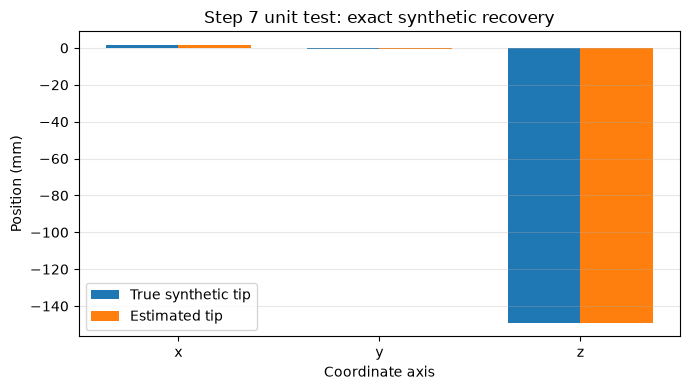

In [92]:
# Unit Test 7/11 - Step 7: exact recovery of a known synthetic pointer tip.
class TestExactTipRecovery(unittest.TestCase):
    def test_exact_tip_recovery(self):
        # Arrange: exact poses and sensor readings generated from a known tip.
        true_tip, ptr_frames, cal_frames, sensed = _synthetic_calibration_case()
        # Act: solve for the pointer-frame tip.
        estimated, _ = compute_pivot_calibration(ptr_frames, cal_frames, sensed)
        # Assert: all coordinates match the known answer.
        np.testing.assert_allclose(estimated.vec, true_tip.vec, atol=1e-10)


exact_tip_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestExactTipRecovery)
)
if not exact_tip_result.wasSuccessful():
    raise AssertionError("Exact-tip-recovery unit test failed.")

# Print and plot the exact-recovery data for an immediate visual comparison.
unit_true_tip, unit_ptr_frames, unit_cal_frames, unit_sensed = _synthetic_calibration_case()
unit_tip_estimate, _ = compute_pivot_calibration(unit_ptr_frames, unit_cal_frames, unit_sensed)
print("\nStep 7 unit-test reference data (mm)")
print("Axis   True      Estimated    Absolute error")
for axis_name, truth, estimate in zip(
    "xyz", unit_true_tip.vec.ravel(), unit_tip_estimate.vec.ravel()
):
    print(f"{axis_name:>4} {truth:9.4f} {estimate:12.4f} {abs(estimate - truth):15.3e}")

figure, axis = plt.subplots(figsize=(7, 4))
axis.bar(np.arange(3) - 0.18, unit_true_tip.vec.ravel(), width=0.36, label="True synthetic tip")
axis.bar(np.arange(3) + 0.18, unit_tip_estimate.vec.ravel(), width=0.36, label="Estimated tip")
axis.set(
    title="Step 7 unit test: exact synthetic recovery",
    xlabel="Coordinate axis", ylabel="Position (mm)",
)
axis.set_xticks(np.arange(3), ["x", "y", "z"])
axis.grid(axis="y", alpha=0.3)
axis.legend()
plt.tight_layout()
plt.show()


In [93]:
# Unit Test 8/11 - Step 7: zero covariance for identical exact estimates.
class TestNoiselessCovariance(unittest.TestCase):
    def test_noiseless_covariance_is_zero(self):
        # Arrange/Act: every exact observation implies the same local tip.
        _, ptr_frames, cal_frames, sensed = _synthetic_calibration_case()
        _, covariance = compute_pivot_calibration(ptr_frames, cal_frames, sensed)
        # Assert: identical estimates have zero empirical covariance.
        np.testing.assert_allclose(covariance, np.zeros((3, 3)), atol=1e-20)


noiseless_covariance_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestNoiselessCovariance)
)
if not noiseless_covariance_result.wasSuccessful():
    raise AssertionError("Noiseless-covariance unit test failed.")


test_noiseless_covariance_is_zero (__main__.TestNoiselessCovariance.test_noiseless_covariance_is_zero) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [94]:
# Unit Test 9/11 - Step 7: filtering invalid calibration-sensor readings.
class TestInvalidSensorFiltering(unittest.TestCase):
    def test_invalid_sensor_entries_are_filtered(self):
        # Arrange: append one missing reading and one out-of-range 10 mm reading.
        true_tip, ptr_frames, cal_frames, sensed = _synthetic_calibration_case()
        estimated, _ = compute_pivot_calibration(
            ptr_frames + [Frame.eye(), Frame.eye()],
            cal_frames + [Frame.eye(), Frame.eye()],
            sensed + [None, vct3(10.0, 0.0, 0.0)],
        )
        # Assert: invalid additions are ignored, so the answer is unchanged.
        np.testing.assert_allclose(estimated.vec, true_tip.vec, atol=1e-10)


invalid_sensor_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestInvalidSensorFiltering)
)
if not invalid_sensor_result.wasSuccessful():
    raise AssertionError("Invalid-sensor-filtering unit test failed.")


test_invalid_sensor_entries_are_filtered (__main__.TestInvalidSensorFiltering.test_invalid_sensor_entries_are_filtered) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [95]:
# Unit Test 10/11 - Step 7: rejection of mismatched paired-list lengths.
class TestCalibrationLengthMismatch(unittest.TestCase):
    def test_length_mismatch_is_rejected(self):
        # Arrange: lists of lengths 1, 0, and 1 break observation correspondence.
        # Assert: the solver rejects the inconsistent inputs before calculation.
        with self.assertRaises(ValueError):
            compute_pivot_calibration([Frame.eye()], [], [vct3()])


length_mismatch_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestCalibrationLengthMismatch)
)
if not length_mismatch_result.wasSuccessful():
    raise AssertionError("Calibration-length-mismatch unit test failed.")


test_length_mismatch_is_rejected (__main__.TestCalibrationLengthMismatch.test_length_mismatch_is_rejected) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [96]:
# Unit Test 11/11 - Step 7: empirical covariance-of-the-mean formula.
class TestEmpiricalCovarianceFormula(unittest.TestCase):
    def test_empirical_covariance_formula(self):
        # Arrange: x estimates are -1, 0, and +1 mm around the true tip.
        # Their sample variance is 1, so covariance of the mean is 1/3.
        true_tip = vct3(0.0, 0.0, -150.0)
        ptr_frames = [Frame(Rot.eye(), -true_tip) for _ in range(3)]
        sensed = [vct3(-1.0, 0.0, 0.0), vct3(), vct3(1.0, 0.0, 0.0)]
        # Act: calculate the mean tip and covariance of that mean.
        estimated, covariance = compute_pivot_calibration(
            ptr_frames, [Frame.eye()] * 3, sensed
        )
        # Assert: the mean is exact and x covariance equals 1/3 mm^2.
        np.testing.assert_allclose(estimated.vec, true_tip.vec, atol=1e-12)
        self.assertAlmostEqual(covariance[0, 0], 1.0 / 3.0, places=12)


empirical_covariance_result = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(TestEmpiricalCovarianceFormula)
)
if not empirical_covariance_result.wasSuccessful():
    raise AssertionError("Empirical-covariance unit test failed.")


test_empirical_covariance_formula (__main__.TestEmpiricalCovarianceFormula.test_empirical_covariance_formula) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK
